In [6]:
# --- IMPORTS ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import C_D_optimizer
from params import DropletParams

p_k: nan


IndexError: index 0 is out of bounds for axis 0 with size 0

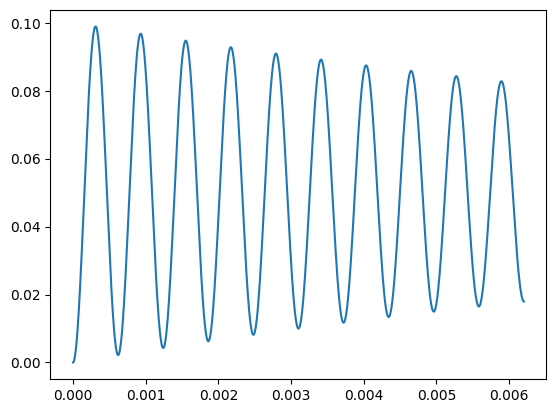

In [7]:
# --- DEFINE INITIAL CONDITIONS ---
#From the Graph, this is the point we want to replicate
We = 0.6
Oh = 0.008
target_deformation = 0.05  # 5% of change, normalized by droplet radius

#Physical intial conditions, from properties of Water
rho_g = 1.18  # kg/m^3, density of air
rho_l = 997  # kg/m^3, density of water
sigma = 0.0708  # kg/s^2, surface tension of water
mu_l = 0.000894  # Pa*s, the dynamic viscosity of water

#Parameters calculated from physical parameters
r_prnt = (mu_l / Oh)**2 * (1/(rho_l*sigma))  # m, radius of water droplet
vel = np.sqrt(sigma*We/(rho_g*r_prnt))  # m/s, velocity of water droplet


# --- DEFINE CONSTANTS ---
C_d_init = 5  # inital "damping" constant
C_k_init = 8  # inital "spring" constant
C_b_init = 2  # inital linear constant
C_F_init = 3  # inital "forcing" constant

y_0_init = 0

A = C_d_init * mu_l / (rho_l * r_prnt**2)
B = C_k_init * sigma / (rho_l * r_prnt**3)
C = (C_b_init * rho_g * vel**2) / (C_F_init * rho_l * r_prnt**2)
omega = np.sqrt(C_k_init*sigma/(rho_l*r_prnt**3))  # 1/s, oscillation frequency


# ---DEFINE TIME SPACE ---
duration = 10*(2*np.pi/omega)  # s, the time we want to watch this particle (10 cycles)
len_t = 1000  # length of time vector

timespace = np.linspace(0, duration, len_t)  # s, time vector
dt = timespace[1] - timespace[0]  # s, one timestep


# --- SOLVE AND PLOT ODE ---
y_vals = (C/B) + np.exp(-A*timespace/2) * ( (y_0_init - (C/B))*np.cos(omega*timespace) + (1/omega)*(y_0_init + (A/2)*(y_0_init-(C/B))*np.sin(omega*timespace)) )

plt.plot(timespace, y_vals)


# --- GET PARAMETERS TO FEED INTO OPTIMIZER ---
params = DropletParams(
    target_deformation = target_deformation,
    y_0_init = y_0_init,
    A = A,
    A_wo_C_d = A/C_d_init,
    B = B,
    C = C,
    omega = omega,
    timespace = timespace
)
max_err = 0.001  # maximum difference allowed between target deformation and current deformation
CD = C_D_optimizer.find_C_d(C_d_init, max_err, params)



# --- OUTPUT EXPERIMENTATION ---
print(f"CD: {CD}")